## Demo 3: Principal Components Analysis

Sedona Ewbank (snewbank@stanford.edu), 24-07-30

In [29]:
# #set up paths
import importlib
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# #This block only important for running as script
# script_dir = os.path.dirname(os.path.abspath(__file__))
# mariposa_dir = os.path.dirname(script_dir)
# utils_dir = os.path.join(mariposa_dir, 'utils')
# sys.path.append(utils_dir)
# sys.path.append(mariposa_dir)

from scipy.spatial import distance

#import utils
from utils import analysis, plot, metadata

importlib.reload(analysis)
importlib.reload(plot)
importlib.reload(metadata)

<module 'utils.metadata' from '/Users/snewbank/PycharmProjects/MARIPoSA/utils/metadata.py'>

In [28]:
config_path="/Users/snewbank/Behavior/MARIPOSA_test/240904_VAME-full/config_PS.yaml"
save_path="/Users/snewbank/Behavior/MARIPOSA_test/240904_VAME-full/demo_sni/"
save=False

#Load config
config = metadata.load_project(config_path)


In [4]:
for key in config["subgroups"].keys():
    if "baseline" in key:
        print(key)
        print(len(config["subgroups"][key]))

baseline_all_sni
41
baseline_shamsal
6
baseline_sni_ketIP
10
baseline_sni_salIP
10
baseline_sni_salIV_FUS
6
baseline_sni_ketIV_FUS
7
baseline_sni_lipkIV_FUS
8


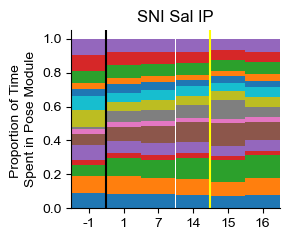

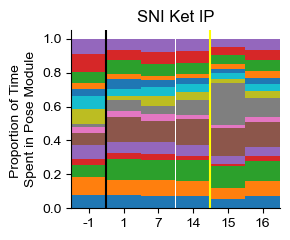

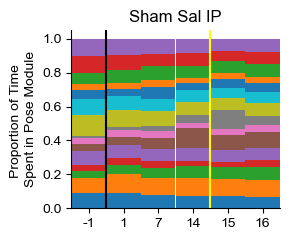

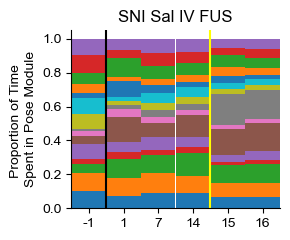

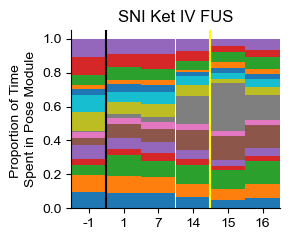

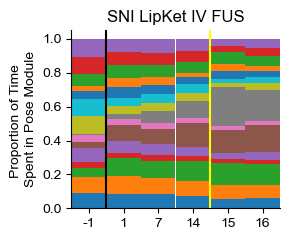

In [22]:
# ['baseline_shamsal', 'd1_shamsal', 'd7_shamsal', 'd14_shamsal', 'd15_shamsal', 'd16_shamsal', 
#  'baseline_sni_ketIP', 'd1_sni_ketIP', 'd7_sni_ketIP', 'd14_sni_ketIP', 'd15_sni_ketIP', 'd16_sni_ketIP', 
#  'baseline_sni_salIP', 'd1_sni_salIP', 'd7_sni_salIP', 'd14_sni_salIP', 'd15_sni_salIP', 'd16_sni_salIP', 
#  'baseline_sni_salIV_FUS', 'd1_sni_salIV_FUS', 'd7_sni_salIV_FUS', 'd14_sni_salIV_FUS', 'd15_sni_salIV_FUS', 'd16_sni_salIV_FUS', 'baseline_sni_ketIV_FUS', 'd1_sni_ketIV_FUS', 'd7_sni_ketIV_FUS', 'd14_sni_ketIV_FUS', 'd15_sni_ketIV_FUS', 'd16_sni_ketIV_FUS', 'baseline_sni_lipkIV_FUS', 'd1_sni_lipkIV_FUS', 'd7_sni_lipkIV_FUS', 'd14_sni_lipkIV_FUS', 'd15_sni_lipkIV_FUS', 'd16_sni_lipkIV_FUS']
# 
# figW=3
# figH=2.5
# lines=True
# 
# groupname="SNI Sal IP"
# group=['baseline_sni_salIP', 'd1_sni_salIP', 'd7_sni_salIP', 'd14_sni_salIP', 'd15_sni_salIP', 'd16_sni_salIP']
# labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=group)
# fig = plot.plot_module_usage_stacked(config, labels_df, 0,1200,alt_xticks=[-1,1,7,14,15,16],title=groupname,figW=figW,figH=figH,legend=False)
# if lines==True:
#     plt.axvline(0.5,color="black")
#     plt.axvline(3.5,color="yellow")
# if save == True:
#     plt.savefig(save_path+groupname+"_stacked_pose.png",dpi=500)
# 
# 
# groupname="SNI Ket IP"
# group=['baseline_sni_ketIP', 'd1_sni_ketIP', 'd7_sni_ketIP', 'd14_sni_ketIP', 'd15_sni_ketIP', 'd16_sni_ketIP']
# labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=group)
# fig = plot.plot_module_usage_stacked(config, labels_df, 0,1200,alt_xticks=[-1,1,7,14,15,16],title=groupname,figW=figW,figH=figH,legend=False)
# if lines==True:
#     plt.axvline(0.5,color="black")
#     plt.axvline(3.5,color="yellow")
# if save == True:
#     plt.savefig(save_path+groupname+"_stacked_pose.png",dpi=500)
# 
# 
# groupname="Sham Sal IP"
# group=['baseline_shamsal', 'd1_shamsal', 'd7_shamsal', 'd14_shamsal', 'd15_shamsal', 'd16_shamsal']
# labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=group)
# fig = plot.plot_module_usage_stacked(config, labels_df, 0,1200,alt_xticks=[-1,1,7,14,15,16],title=groupname,figW=figW,figH=figH,legend=False)
# plt.axvline(0.5,color="black")
# plt.axvline(3.5,color="yellow")
# if save == True:
#     plt.savefig(save_path+groupname+"_stacked_pose.png",dpi=500)
# 
# 
# groupname="SNI Sal IV FUS"
# group=['baseline_sni_salIV_FUS', 'd1_sni_salIV_FUS', 'd7_sni_salIV_FUS', 'd14_sni_salIV_FUS', 'd15_sni_salIV_FUS', 'd16_sni_salIV_FUS']
# labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=group)
# fig = plot.plot_module_usage_stacked(config, labels_df, 0,1200,alt_xticks=[-1,1,7,14,15,16],title=groupname,figW=figW,figH=figH,legend=False)
# if lines==True:
#     plt.axvline(0.5,color="black")
#     plt.axvline(3.5,color="yellow")
# if save == True:
#     plt.savefig(save_path+groupname+"_stacked_pose.png",dpi=500)
# 
# 
# groupname="SNI Ket IV FUS"
# group=['baseline_sni_ketIV_FUS', 'd1_sni_ketIV_FUS', 'd7_sni_ketIV_FUS', 'd14_sni_ketIV_FUS', 'd15_sni_ketIV_FUS', 'd16_sni_ketIV_FUS']
# labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=group)
# fig = plot.plot_module_usage_stacked(config, labels_df, 0,1200,alt_xticks=[-1,1,7,14,15,16],title=groupname,figW=figW,figH=figH,legend=False)
# if lines==True:
#     plt.axvline(0.5,color="black")
#     plt.axvline(3.5,color="yellow")
# if save == True:
#     plt.savefig(save_path+groupname+"_stacked_pose.png",dpi=500)
# 
# 
# groupname="SNI LipKet IV FUS"
# group=['baseline_sni_lipkIV_FUS', 'd1_sni_lipkIV_FUS', 'd7_sni_lipkIV_FUS', 'd14_sni_lipkIV_FUS', 'd15_sni_lipkIV_FUS', 'd16_sni_lipkIV_FUS']
# labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=group)
# fig = plot.plot_module_usage_stacked(config, labels_df, 0,1200,alt_xticks=[-1,1,7,14,15,16],title=groupname,figW=figW,figH=figH,legend=False)
# if lines==True:
#     plt.axvline(0.5,color="black")
#     plt.axvline(3.5,color="yellow")
# if save == True:
#     plt.savefig(save_path+groupname+"_stacked_pose.png",dpi=500)
# # 


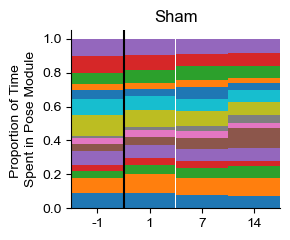

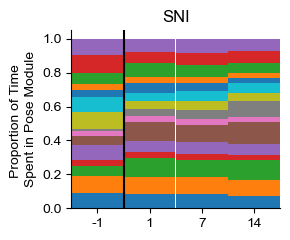

In [23]:
# figW=3
# figH=2.5
# lines=True
# 
# groupname="Sham"
# group=['baseline_shamsal', 'd1_shamsal', 'd7_shamsal', 'd14_shamsal']
# labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=group)
# fig = plot.plot_module_usage_stacked(config, labels_df, 0,1200,alt_xticks=[-1,1,7,14],title=groupname,figW=figW,figH=figH,legend=False)
# if lines==True:
#     plt.axvline(0.5,color="black")
# if save == True:
#     plt.savefig(save_path+groupname+"_stacked_pose.png",dpi=500)
# 
# 
# groupname="SNI"
# group=['baseline_all_sni', 'd1_all_sni', 'd7_all_sni', 'd14_all_sni']
# labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=group)
# fig = plot.plot_module_usage_stacked(config, labels_df, 0,1200,alt_xticks=[-1,1,7,14],title=groupname,figW=figW,figH=figH,legend=False)
# if lines==True:
#     plt.axvline(0.5,color="black")
# if save == True:
#     plt.savefig(save_path+groupname+"_stacked_pose.png",dpi=500)

done with ['2023-07-18_18-19-50_bm04_k10iv_2023-07-18_18-19-50_bm04_k10iv.csv', '2023-07-18_18-19-50_bm04_k10iv']
done with ['2023-06-20_19-10-38_bf04_k1iv_2023-06-20_19-10-38_bf04_k1iv.csv', '2023-06-20_19-10-38_bf04_k1iv']
VAME modules map onto scored behaviors with 'loss' of 0.3304357516995431
Applying 15 remapping rules from config.
1 of 15: Remapping [0] to rear
2 of 15: Remapping [1] to ataxic 4-5
3 of 15: Remapping [2] to explore
4 of 15: Remapping [3] to ataxic 4-5
5 of 15: Remapping [4] to ataxic 4-5
6 of 15: Remapping [5] to explore
7 of 15: Remapping [6] to sleep
8 of 15: Remapping [7] to ataxic 1-3
9 of 15: Remapping [8] to walk
10 of 15: Remapping [9] to walk
11 of 15: Remapping [10] to ataxic 4-5
12 of 15: Remapping [11] to groom
13 of 15: Remapping [12] to ataxic 4-5
14 of 15: Remapping [13] to walk
15 of 15: Remapping [14] to ataxic 4-5
Applying 15 remapping rules from config.
1 of 15: Remapping [0] to rear
2 of 15: Remapping [1] to ataxic 4-5
3 of 15: Remapping [2] to 

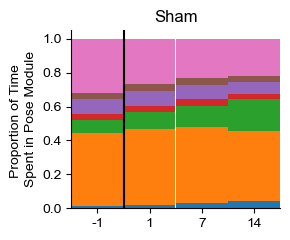

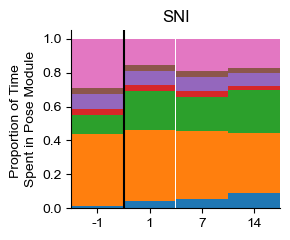

In [24]:
# BORIS_to_pose_mat, BORIS_to_pose_mat_normalized, loss = analysis.BORIS_to_pose(config)
# 
# figW=3
# figH=2.5
# 
# groupname="Sham"
# group=['baseline_shamsal', 'd1_shamsal', 'd7_shamsal', 'd14_shamsal']
# labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=group)
# labels_df = analysis.make_remappings_from_BORIS(config, labels_df, BORIS_to_pose_mat)
# fig = plot.plot_module_usage_stacked(config, labels_df, 0,1200,alt_xticks=[-1,1,7,14],title=groupname,figW=figW,figH=figH,legend=False)
# if lines==True:
#     plt.axvline(0.5,color="black")
# if save == True:
#     plt.savefig(save_path+groupname+"_stacked_pose_remapped.png",dpi=500)
# 
# 
# groupname="SNI"
# group=['baseline_all_sni', 'd1_all_sni', 'd7_all_sni', 'd14_all_sni']
# labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=group)
# labels_df = analysis.make_remappings_from_BORIS(config, labels_df, BORIS_to_pose_mat)
# fig = plot.plot_module_usage_stacked(config, labels_df, 0,1200,alt_xticks=[-1,1,7,14],title=groupname,figW=figW,figH=figH,legend=False)
# if lines==True:
#     plt.axvline(0.5,color="black")
# if save == True:
#     plt.savefig(save_path+groupname+"_stacked_pose_remapped.png",dpi=500)

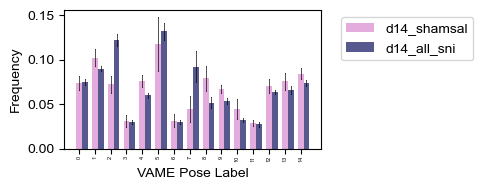

In [25]:
#selected_subgroups=['d1_shamsal', 'd7_shamsal', 'd14_shamsal','d1_all_sni','d7_all_sni', 'd14_all_sni']
selected_subgroups=['d14_shamsal','d14_all_sni']
labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=selected_subgroups)
fig = plot.plot_module_usage_subgroups(config, labels_df, 0, 1200,figW=5,figH=2,cmap="tab20b_r",legend_pos="outside",style="bar_error")
if save == True:
    plt.savefig(save_path+groupname+"_points pose VAME",dpi=500)

Applying 15 remapping rules from config.
1 of 15: Remapping [0] to rear
2 of 15: Remapping [1] to ataxic 4-5
3 of 15: Remapping [2] to explore
4 of 15: Remapping [3] to ataxic 4-5
5 of 15: Remapping [4] to ataxic 4-5
6 of 15: Remapping [5] to explore
7 of 15: Remapping [6] to sleep
8 of 15: Remapping [7] to ataxic 1-3
9 of 15: Remapping [8] to walk
10 of 15: Remapping [9] to walk
11 of 15: Remapping [10] to ataxic 4-5
12 of 15: Remapping [11] to groom
13 of 15: Remapping [12] to ataxic 4-5
14 of 15: Remapping [13] to walk
15 of 15: Remapping [14] to ataxic 4-5


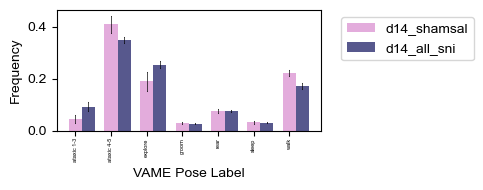

In [26]:
#selected_subgroups=['d1_shamsal', 'd7_shamsal', 'd14_shamsal','d1_all_sni','d7_all_sni', 'd14_all_sni']
selected_subgroups=['d14_shamsal','d14_all_sni']
labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=selected_subgroups)
labels_df = analysis.make_remappings_from_BORIS(config, labels_df, BORIS_to_pose_mat)
fig = plot.plot_module_usage_subgroups(config, labels_df, 0, 1200,figW=5,figH=2,cmap="tab20b_r",legend_pos="outside",style="bar_error")
if save == True:
    plt.savefig(save_path+groupname+"_points pose VAME_remapped.png",dpi=500)

Applying 15 remapping rules from config.
1 of 15: Remapping [0] to rear
2 of 15: Remapping [1] to ataxic 4-5
3 of 15: Remapping [2] to explore
4 of 15: Remapping [3] to ataxic 4-5
5 of 15: Remapping [4] to ataxic 4-5
6 of 15: Remapping [5] to explore
7 of 15: Remapping [6] to sleep
8 of 15: Remapping [7] to ataxic 1-3
9 of 15: Remapping [8] to walk
10 of 15: Remapping [9] to walk
11 of 15: Remapping [10] to ataxic 4-5
12 of 15: Remapping [11] to groom
13 of 15: Remapping [12] to ataxic 4-5
14 of 15: Remapping [13] to walk
15 of 15: Remapping [14] to ataxic 4-5
Applying 15 remapping rules from config.
1 of 15: Remapping [0] to rear
2 of 15: Remapping [1] to ataxic 4-5
3 of 15: Remapping [2] to explore
4 of 15: Remapping [3] to ataxic 4-5
5 of 15: Remapping [4] to ataxic 4-5
6 of 15: Remapping [5] to explore
7 of 15: Remapping [6] to sleep
8 of 15: Remapping [7] to ataxic 1-3
9 of 15: Remapping [8] to walk
10 of 15: Remapping [9] to walk
11 of 15: Remapping [10] to ataxic 4-5
12 of 15: R

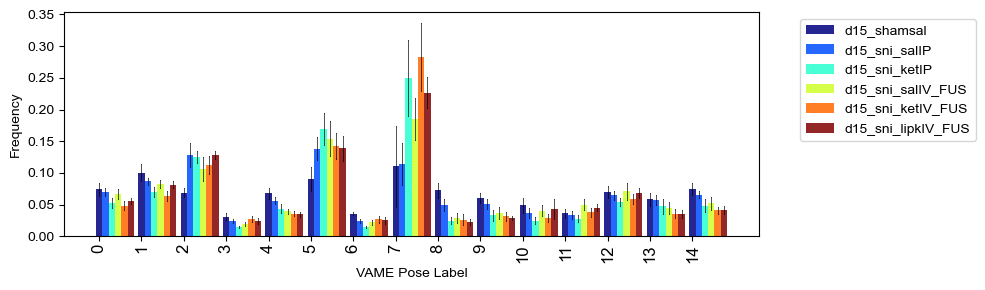

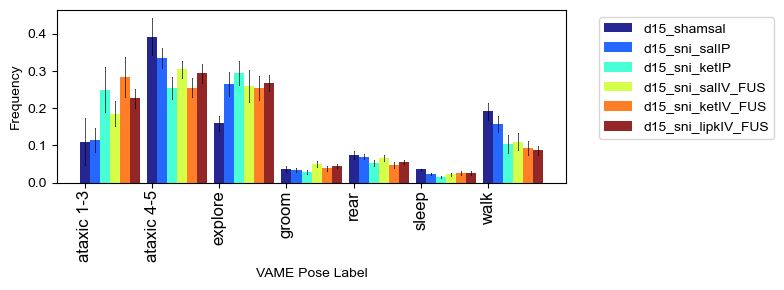

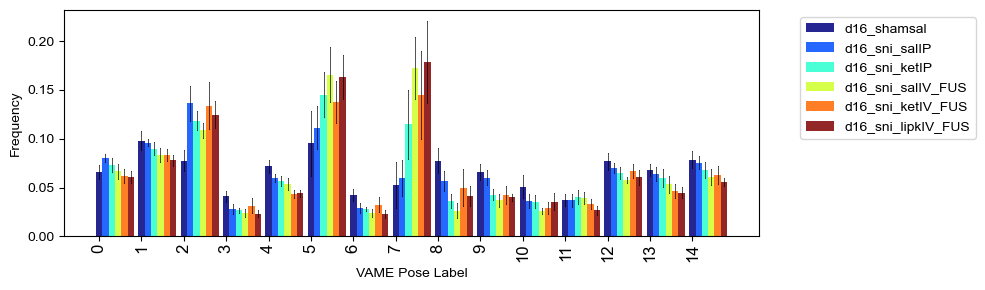

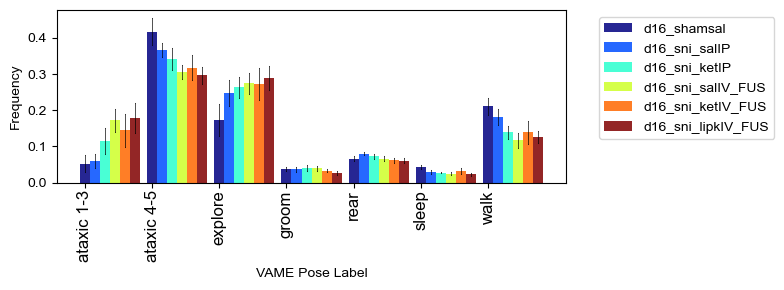

In [27]:
selected_subgroups=['d15_shamsal', 'd15_sni_salIP', 'd15_sni_ketIP', 'd15_sni_salIV_FUS', 'd15_sni_ketIV_FUS', 'd15_sni_lipkIV_FUS']
labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=selected_subgroups)
fig = plot.plot_module_usage_subgroups(config, labels_df, 0, 1200,figW=10,figH=3,cmap="jet",legend_pos="outside",style="bar_error")
if save == True:
    plt.savefig(save_path+"subgr d15 VAME.png",dpi=500)
    
    
selected_subgroups=['d15_shamsal', 'd15_sni_salIP', 'd15_sni_ketIP', 'd15_sni_salIV_FUS', 'd15_sni_ketIV_FUS', 'd15_sni_lipkIV_FUS']
labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=selected_subgroups)
labels_df = analysis.make_remappings_from_BORIS(config, labels_df, BORIS_to_pose_mat)
fig = plot.plot_module_usage_subgroups(config, labels_df, 0, 1200,figW=8,figH=3,cmap="jet",legend_pos="outside",style="bar_error")
if save == True:
    plt.savefig(save_path+"subgr d15 VAME_remapped.png",dpi=500)
    
selected_subgroups=['d16_shamsal', 'd16_sni_salIP', 'd16_sni_ketIP', 'd16_sni_salIV_FUS','d16_sni_ketIV_FUS', 'd16_sni_lipkIV_FUS']
labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=selected_subgroups)
fig = plot.plot_module_usage_subgroups(config, labels_df, 0, 1200,figW=10,figH=3,cmap="jet",legend_pos="outside",style="bar_error")
if save == True:
    plt.savefig(save_path+"subgr d16 VAME",dpi=500)
    
    
selected_subgroups=['d16_shamsal', 'd16_sni_salIP', 'd16_sni_ketIP', 'd16_sni_salIV_FUS','d16_sni_ketIV_FUS', 'd16_sni_lipkIV_FUS']
labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=selected_subgroups)
labels_df = analysis.make_remappings_from_BORIS(config, labels_df, BORIS_to_pose_mat)
fig = plot.plot_module_usage_subgroups(config, labels_df, 0, 1200,figW=8,figH=3,cmap="jet",legend_pos="outside",style="bar_error")
if save == True:
    plt.savefig(save_path+"subgr d16 VAME_remapped.png",dpi=500)

done with ['2023-07-18_18-19-50_bm04_k10iv_2023-07-18_18-19-50_bm04_k10iv.csv', '2023-07-18_18-19-50_bm04_k10iv']
done with ['2023-06-20_19-10-38_bf04_k1iv_2023-06-20_19-10-38_bf04_k1iv.csv', '2023-06-20_19-10-38_bf04_k1iv']
VAME modules map onto scored behaviors with 'loss' of 0.3304357516995431
Applying 15 remapping rules from config.
1 of 15: Remapping [0] to rear
2 of 15: Remapping [1] to ataxic 4-5
3 of 15: Remapping [2] to explore
4 of 15: Remapping [3] to ataxic 4-5
5 of 15: Remapping [4] to ataxic 4-5
6 of 15: Remapping [5] to explore
7 of 15: Remapping [6] to sleep
8 of 15: Remapping [7] to ataxic 1-3
9 of 15: Remapping [8] to walk
10 of 15: Remapping [9] to walk
11 of 15: Remapping [10] to ataxic 4-5
12 of 15: Remapping [11] to groom
13 of 15: Remapping [12] to ataxic 4-5
14 of 15: Remapping [13] to walk
15 of 15: Remapping [14] to ataxic 4-5


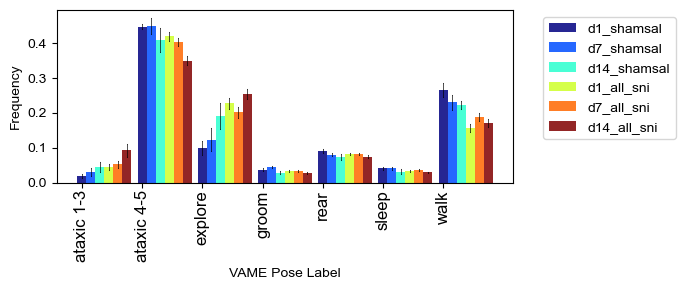

In [28]:
BORIS_to_pose_mat, BORIS_to_pose_mat_normalized, loss = analysis.BORIS_to_pose(config)

selected_subgroups=['d1_shamsal', 'd7_shamsal', 'd14_shamsal','d1_all_sni','d7_all_sni', 'd14_all_sni']
labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=selected_subgroups)
labels_df = analysis.make_remappings_from_BORIS(config, labels_df, BORIS_to_pose_mat)
fig = plot.plot_module_usage_subgroups(config, labels_df, 0, 1200,figW=7,figH=3,cmap="jet",legend_pos="outside",style="bar_error")

P-value for cluster 2 difference is 0.0433; t score is -2.2221
P-value for cluster 6 difference is 0.0219; t score is 2.5774
P-value for transition from cluster 2 to cluster 5 is 0.0306; t score is -2.4038
P-value for transition from cluster 3 to cluster 1 is 0.0088; t score is 3.04
P-value for transition from cluster 5 to cluster 2 is 0.0221; t score is -2.574
P-value for transition from cluster 12 to cluster 13 is 0.0495; t score is 2.1505
P-value for cluster 2 difference is 0.0401; t score is -2.2622
P-value for transition from cluster 1 to cluster 2 is 0.0189; t score is -2.654
P-value for transition from cluster 2 to cluster 0 is 0.0103; t score is -2.9612
P-value for transition from cluster 4 to cluster 10 is 0.0379; t score is 2.2927
P-value for transition from cluster 13 to cluster 4 is 0.0279; t score is 2.4523
P-value for transition from cluster 14 to cluster 9 is 0.0416; t score is -2.2429
P-value for cluster 2 difference is 0.0012; t score is -4.0477
P-value for cluster 3 d

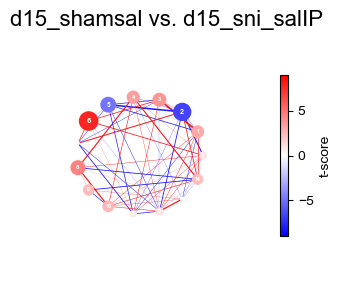

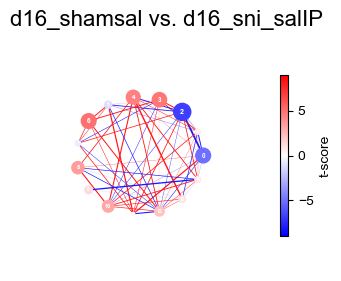

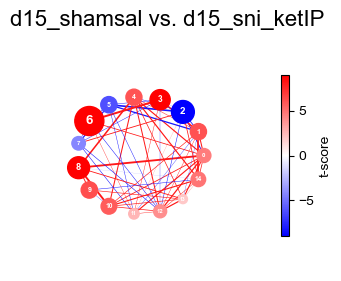

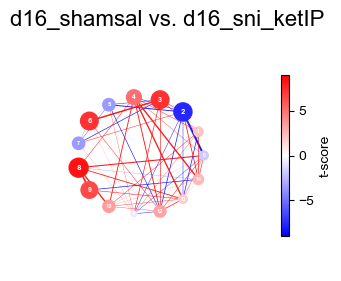

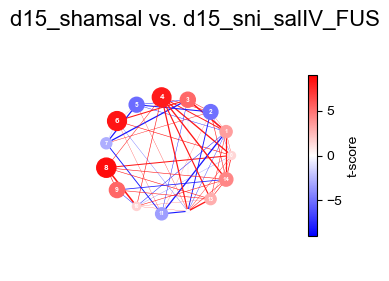

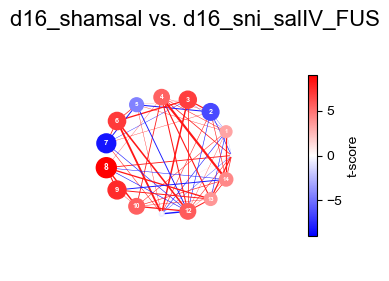

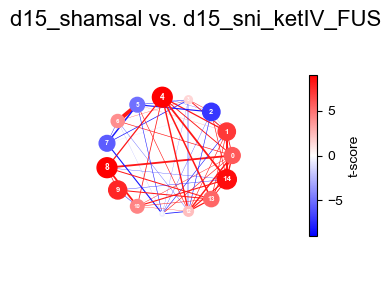

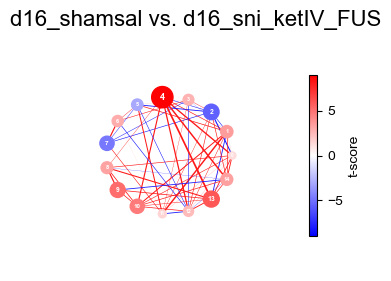

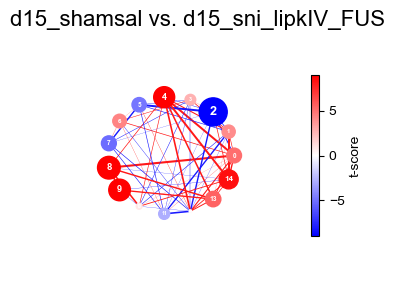

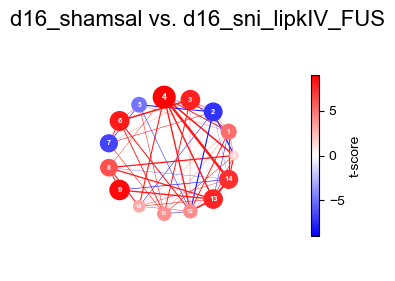

In [19]:
figW=3
figH=2.5
lines = True

# all_comparison_groups=[['baseline_sni_salIP', 'd15_sni_salIP'],
#                        ['baseline_sni_salIP', 'd16_sni_salIP'],
#                        ['baseline_sni_ketIP', 'd15_sni_ketIP'],
#                        ['baseline_sni_ketIP', 'd16_sni_ketIP'],
#                        ['baseline_shamsal', 'd15_shamsal'],
#                        ['baseline_shamsal', 'd16_shamsal'],
#                        ['baseline_sni_salIV_FUS', 'd15_sni_salIV_FUS'],
#                        ['baseline_sni_salIV_FUS', 'd16_sni_salIV_FUS'],
#                        ['baseline_sni_ketIV_FUS', 'd15_sni_ketIV_FUS'],
#                        ['baseline_sni_ketIV_FUS', 'd16_sni_ketIV_FUS'],
#                        ['baseline_sni_lipkIV_FUS', 'd15_sni_lipkIV_FUS'],
#                        ['baseline_sni_lipkIV_FUS', 'd16_sni_lipkIV_FUS']]

all_comparison_groups=[['d15_shamsal', 'd15_sni_salIP'],
                       ['d16_shamsal', 'd16_sni_salIP'],
                       ['d15_shamsal', 'd15_sni_ketIP'],
                       ['d16_shamsal', 'd16_sni_ketIP'],
                       ['d15_shamsal', 'd15_sni_salIV_FUS'],
                       ['d16_shamsal', 'd16_sni_salIV_FUS'],
                       ['d15_shamsal', 'd15_sni_ketIV_FUS'],
                       ['d16_shamsal', 'd16_sni_ketIV_FUS'],
                       ['d15_shamsal', 'd15_sni_lipkIV_FUS'],
                       ['d16_shamsal', 'd16_sni_lipkIV_FUS']]

for comparison_group in all_comparison_groups:
    labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=comparison_group)
    fig = plot.network_pairwise_comparison(config, labels_df, 0, 1200, comparison_group,cmap="bwr",tscale=9)
    if save == True:
        plt.savefig(save_path+comparison_group[0]+" vs "+comparison_group[1]+" network_comparison.png",dpi=500)

Features selected by f-stat were: module2_t60-120, module4_t60-120, module1_t120-180, module3_t120-180, module6_t120-180, module11_t120-180, module1_t180-240, module2_t180-240, module8_t180-240, module9_t180-240, module11_t180-240, module14_t180-240, module2_t240-300, module5_t240-300, module8_t240-300, module10_t240-300, module2_t300-360, module4_t300-360, module5_t300-360, module6_t300-360, module7_t300-360, module8_t300-360, module9_t300-360, module10_t300-360, module11_t300-360, module14_t300-360, module1_t360-420, module2_t360-420, module4_t360-420, module5_t360-420, module6_t360-420, module7_t360-420, module8_t360-420, module9_t360-420, module13_t360-420, module1_t420-480, module4_t420-480, module7_t420-480, module8_t420-480, module9_t420-480, module11_t420-480, module12_t420-480, module0_t480-540, module1_t480-540, module2_t480-540, module3_t480-540, module6_t480-540, module7_t480-540, module8_t480-540, module9_t480-540, module0_t540-600, module8_t540-600, module0_t600-660, modu

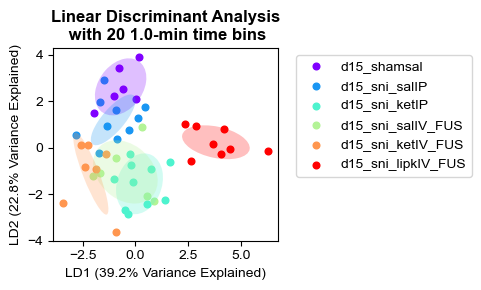

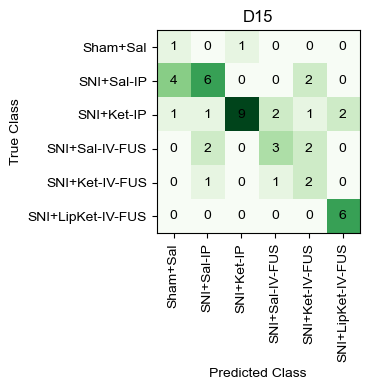

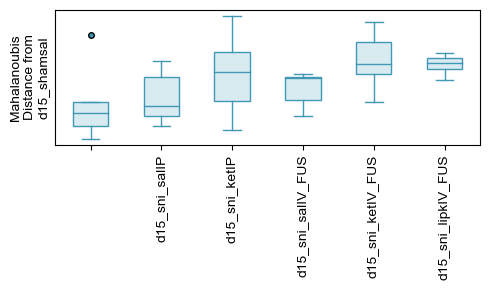

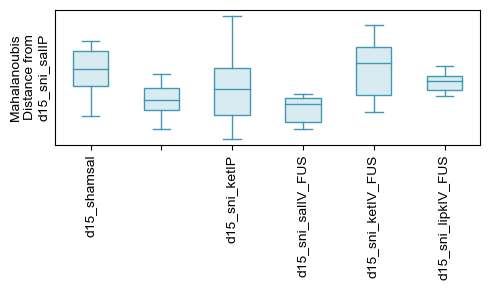

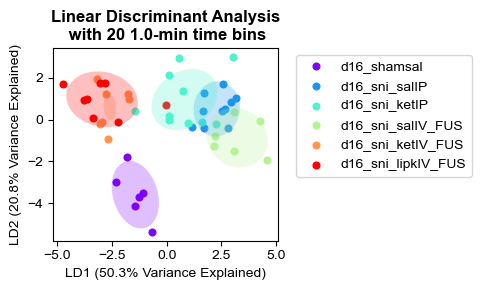

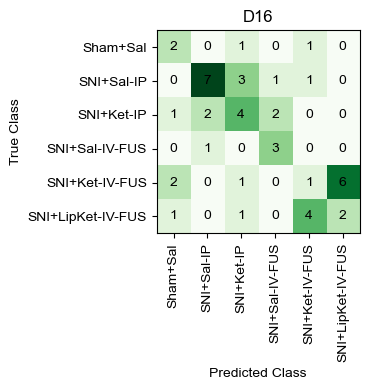

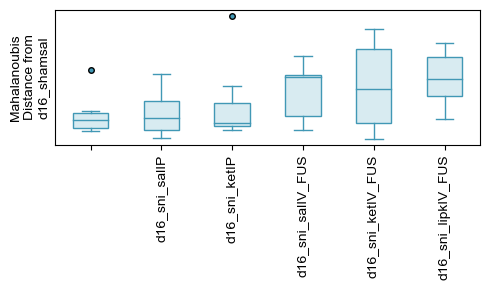

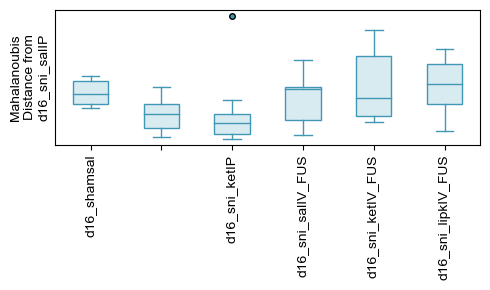

In [27]:
figW=3
figH=2.5
lines=True

all_groups = {"D15": ['d15_shamsal','d15_sni_salIP','d15_sni_ketIP','d15_sni_salIV_FUS','d15_sni_ketIV_FUS','d15_sni_lipkIV_FUS'],
              "D16": ['d16_shamsal','d16_sni_salIP','d16_sni_ketIP','d16_sni_salIV_FUS','d16_sni_ketIV_FUS','d16_sni_lipkIV_FUS']}

figW=5
figH=3
for groupname in list(all_groups.keys()):
    group=all_groups[groupname]
    labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=group)
    lda_result = analysis.lda_labels_timebins(config,labels_df,60,feature_selection=("f",100),selected_subgroups=group,loocv=True,ncomponents=5)
    fig = plot.plot_lda(config, lda_result, cmap="rainbow",figW=figW,figH=figH,draw_ellipse=True)
    if save == True:
        plt.savefig(save_path+"lda_"+groupname+".png",dpi=500)
    class_labels={}
    class_labels_list=['Sham+Sal','SNI+Sal-IP','SNI+Ket-IP','SNI+Sal-IV-FUS','SNI+Ket-IV-FUS','SNI+LipKet-IV-FUS']
    for o,obs in enumerate(group):
        class_labels[obs]=class_labels_list[o]
    plot.plot_conf_mat(lda_result,alt_labels=class_labels,alt_title=groupname,figH=4,figW=4,rotate_xticks=True)
    print(lda_result.loocv_accuracy)
    if save == True:
        plt.savefig(save_path+"lda_loocv_"+groupname+".png",dpi=500)
    dists = lda_result.get_mahalanobis_distance(type="point_to_centroid")
    shamsal_key=[i for i in group if "_shamsal" in i][0]
    plot.plot_dist_boxplot(dists,dist_from=shamsal_key)
    salip_key=[i for i in group if "_sni_salIP" in i][0]
    plot.plot_dist_boxplot(dists,dist_from=salip_key)
    if save == True:
        plt.savefig(save_path+"mahalanob_dist_"+groupname+".png",dpi=500)

In [24]:
np.sum(["CENTROID" in i for i in list(dists.keys())])>0

True

In [ ]:
labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=["baseline_all_sni","d14_all_sni"])
lda_result = analysis.lda_labels_timebins(config,labels_df,1200,selected_subgroups=["baseline_all_sni","d14_all_sni"],ncomponents=1)
fig = plot.plot_lda(config, lda_result, cmap="viridis_r")
class_labels=["Baseline","D14"]
plot.plot_conf_mat(lda_result,alt_title="SNI\nLDA LOOCV",alt_labels=class_labels)
if save == True:
    plt.savefig(save_path+"SNI_LDA_confmat.png",dpi=500)

labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=["baseline_shamsal","d14_shamsal"])
lda_result = analysis.lda_labels_timebins(config,labels_df,1200,selected_subgroups=["baseline_shamsal","d14_shamsal"],ncomponents=1)
fig = plot.plot_lda(config, lda_result, 1200, cmap="viridis_r")
class_labels=["Baseline","D14"]
plot.plot_conf_mat(lda_result,alt_title="SNI\nLDA LOOCV",alt_labels=class_labels)
if save == True:
    plt.savefig(save_path+"Sham_LDA_confmat.png",dpi=500)

In [ ]:
# def pca_pose(config, labels_df, start, stop):
#     """
#     Plots the frequency of the pose modules occurring by group in the labels dataframe output by the label_counter function.
#     :param labels_df: dataframe output from analysis.label_counter
#     :param start: time in seconds to start dataframe from.
#     :param stop: time in seconds to stop dataframe at.
#     :param fps: frames per second of recording.
#     :param figW: figure width
#     :param figH:
#     :param style:
#     :return:
#     """
#     #To get groupnames in order
#     fps = config["fps"]
#     groupnames = []
#     added_groupnames = set()
#     for item in [header[0] for header in labels_df.columns]:
#         if item not in added_groupnames:
#             groupnames.append(item)
#             added_groupnames.add(item)
#     n_groups=len(groupnames)
# 
#     # Frames
#     start_frame = start * fps
#     stop_frame = stop * fps
#     labels_df = labels_df[start_frame:stop_frame]
#     total_frames = stop_frame - start_frame
#     labels_flat = np.array(labels_df)
#     labels_flat = [item for sublist in labels_flat for item in sublist]
#     modules = np.unique(labels_flat)
#     n_modules = len(modules)
# 
#     # Label counting
#     label_counts = []
#     for g in range(n_groups):
#         group_g_n=np.sum([item[0]==groupnames[g] for item in labels_df.columns])
#         label_counts_i = np.zeros([group_g_n, n_modules])
#         for i in range(group_g_n):
#             for m in range(n_modules):
#                 module = modules[m]
#                 try:
#                     module = np.int64(module)
#                 except ValueError:
#                     pass
#                 label_counts_i[i, m] = np.count_nonzero \
#                                            (labels_df[groupnames[g]][[labels_df[groupnames[g]].columns[i]]] == module) / total_frames
#         label_counts.append(label_counts_i)
#     label_counts = np.concatenate(label_counts, axis=0)
#     pca = PCA(n_components=2)
#     label_counts_transformed = pca.fit_transform(label_counts)
#     return pca, label_counts_transformed
# 
# selected_subgroups=['baseline_shamsal', 'd1_shamsal', 'd7_shamsal', 'd14_shamsal', 'd15_shamsal', 'd16_shamsal', 
#                     'baseline_sni_ketIP', 'd1_sni_ketIP', 'd7_sni_ketIP', 'd14_sni_ketIP', 'd15_sni_ketIP', 'd16_sni_ketIP', 
#                     'baseline_sni_salIP', 'd1_sni_salIP', 'd7_sni_salIP', 'd14_sni_salIP', 'd15_sni_salIP', 'd16_sni_salIP']
# # ['baseline_sni_salIV_FUS', 'd1_sni_salIV_FUS', 'd7_sni_salIV_FUS', 'd14_sni_salIV_FUS', 'd15_sni_salIV_FUS', 'd16_sni_salIV_FUS',
# # 'baseline_sni_ketIV_FUS', 'd1_sni_ketIV_FUS', 'd7_sni_ketIV_FUS', 'd14_sni_ketIV_FUS', 'd15_sni_ketIV_FUS', 'd16_sni_ketIV_FUS',
# # 'baseline_sni_lipkIV_FUS', 'd1_sni_lipkIV_FUS', 'd7_sni_lipkIV_FUS', 'd14_sni_lipkIV_FUS', 'd15_sni_lipkIV_FUS', 'd16_sni_lipkIV_FUS']
# labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=selected_subgroups)
# pca, label_counts_transformed = pca_pose(config, labels_df, 0, 1200)

In [ ]:
# def pca_pose(config, labels_df, start, stop, n_components=2):
#     fps = config["fps"]
#     groupnames = []
#     added_groupnames = set()
#     for item in [header[0] for header in labels_df.columns]:
#         if item not in added_groupnames:
#             groupnames.append(item)
#             added_groupnames.add(item)
#     n_groups=len(groupnames)
#     
#     # Frames
#     start_frame = start * fps
#     stop_frame = stop * fps
#     labels_df = labels_df[start_frame:stop_frame]
#     total_frames = stop_frame - start_frame
#     labels_flat = np.array(labels_df)
#     labels_flat = [item for sublist in labels_flat for item in sublist]
#     modules = np.unique(labels_flat)
#     n_modules = len(modules)
#     
#     # Label counting
#     idx1=[]
#     idx2=[]
#     for g in range(n_groups):
#         group_g_n=np.sum([item[0]==groupnames[g] for item in labels_df.columns])
#         label_counts_i = np.zeros([group_g_n, n_modules])
#         for i in range(group_g_n):
#             idx1.append(groupnames[g])
#             idx2.append(labels_df[groupnames[g]].columns[i])
#             for m in range(n_modules):
#                 module = modules[m]
#                 try:
#                     module = np.int64(module)
#                 except ValueError:
#                     pass
#                 label_counts_i[i, m] = np.count_nonzero \
#                                            (labels_df[groupnames[g]][
#                                                 [labels_df[groupnames[g]].columns[i]]] == module) / total_frames
#         if g==0:
#             label_counts = label_counts_i
#         else:
#             label_counts = np.concatenate((label_counts, label_counts_i),axis=0)
#     
#     label_counts_centered=label_counts-np.mean(label_counts,axis=0)
#     scaler = StandardScaler()
#     label_counts_scaled = scaler.fit_transform(label_counts_centered)
#     pca = PCA(n_components=n_components)
#     label_counts_transformed = pca.fit_transform(label_counts_scaled)
#     pca_df = pd.DataFrame(label_counts_transformed,columns=["PC1","PC2"])
#     pca_df["group"]=idx1
#     pca_df["sess"]=idx2
#     return pca, label_counts_transformed, pca_df
# 
# start = 0
# stop = 1200
# selected_subgroups=['baseline_shamsal', 'd1_shamsal', 'd7_shamsal', 'd14_shamsal', 'd15_shamsal', 'd16_shamsal', 
#                     'baseline_sni_ketIP', 'd1_sni_ketIP', 'd7_sni_ketIP', 'd14_sni_ketIP', 'd15_sni_ketIP', 'd16_sni_ketIP', 
#                     'baseline_sni_salIP', 'd1_sni_salIP', 'd7_sni_salIP', 'd14_sni_salIP', 'd15_sni_salIP', 'd16_sni_salIP']
# labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=selected_subgroups)
# #labels_df = analysis.make_remappings_from_BORIS(config, labels_df, BORIS_to_pose_mat)
# pca, label_counts_transformed, pca_df = pca_pose(config, labels_df, 0, 1200)

In [ ]:
# config["subgroups"].keys()

In [ ]:
# shamsal=['baseline_shamsal', 'd1_shamsal', 'd7_shamsal', 'd14_shamsal', 'd15_shamsal', 'd16_shamsal'] 
# sniket=['baseline_sni_ketIP', 'd1_sni_ketIP', 'd7_sni_ketIP', 'd14_sni_ketIP', 'd15_sni_ketIP', 'd16_sni_ketIP']
# snisal=['baseline_sni_salIP', 'd1_sni_salIP', 'd7_sni_salIP', 'd14_sni_salIP', 'd15_sni_salIP', 'd16_sni_salIP']

In [ ]:
# groups = [shamsal,snisal,sniket]
# groupnames = ['Sham SAL','SNI SAL (IP)','SNI KET (IP)']
# markers = ["s","^","o"]
# num_labels=["B", 1, 7, 14, 15, 16]
# 
# plt.figure(figsize=(4,4),dpi=500)
# 
# cmap=plt.get_cmap('viridis')
# colors = [cmap([i]) for i in np.linspace(0, 1, len(num_labels))]
# for g, group in enumerate(groups):
#     pc1_mean=[]
#     pc2_mean=[]
#     for s, sess in enumerate(group):
#         pc1_i = pca_df[pca_df["group"]==sess]["PC1"].mean()
#         pc2_i = pca_df[pca_df["group"]==sess]["PC2"].mean()
#         pc1_mean.append(pca_df[pca_df["group"]==sess]["PC1"].mean())
#         pc2_mean.append(pca_df[pca_df["group"]==sess]["PC2"].mean())
#         plt.text(pc1_i,pc2_i,str(num_labels[s]),va="center",ha="center",color="white")
#     plt.plot(pc1_mean,pc2_mean,marker="o",markersize=12,label=groupnames[g],alpha=0.8)
#     plt.scatter(pc1_mean[4],pc2_mean[4],marker="o",s=12**2,color="none",edgecolor="red",zorder=2)
# plt.legend(loc="upper right",bbox_to_anchor=(1.5,1))
# plt.xlabel("PC1")
# plt.ylabel("PC2")

In [ ]:
# start = 0
# stop = 1200
# selected_subgroups=['baseline_sni_salIV_FUS', 'd1_sni_salIV_FUS', 'd7_sni_salIV_FUS', 'd14_sni_salIV_FUS', 'd15_sni_salIV_FUS', 'd16_sni_salIV_FUS', 'baseline_sni_ketIV_FUS', 'd1_sni_ketIV_FUS', 'd7_sni_ketIV_FUS', 'd14_sni_ketIV_FUS', 'd15_sni_ketIV_FUS', 'd16_sni_ketIV_FUS', 'baseline_sni_lipkIV_FUS', 'd1_sni_lipkIV_FUS', 'd7_sni_lipkIV_FUS', 'd14_sni_lipkIV_FUS', 'd15_sni_lipkIV_FUS', 'd16_sni_lipkIV_FUS']
# labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=selected_subgroups)
# #labels_df = analysis.make_remappings_from_BORIS(config, labels_df, BORIS_to_pose_mat)
# pca, label_counts_transformed, pca_df = pca_pose(config, labels_df, 0, 1200)

In [ ]:
# snisaliv=['baseline_sni_salIV_FUS', 'd1_sni_salIV_FUS', 'd7_sni_salIV_FUS', 'd14_sni_salIV_FUS', 'd15_sni_salIV_FUS', 'd16_sni_salIV_FUS']
# sniketiv=['baseline_sni_ketIV_FUS', 'd1_sni_ketIV_FUS', 'd7_sni_ketIV_FUS', 'd14_sni_ketIV_FUS', 'd15_sni_ketIV_FUS', 'd16_sni_ketIV_FUS']
# snilipkiv=['baseline_sni_lipkIV_FUS', 'd1_sni_lipkIV_FUS', 'd7_sni_lipkIV_FUS', 'd14_sni_lipkIV_FUS', 'd15_sni_lipkIV_FUS', 'd16_sni_lipkIV_FUS']
# 
# groups = [snisaliv,sniketiv,snilipkiv]
# groupnames = ['SNI SAL IV + FUS','SNI FreeK (IV + FUS)','SNI LipK (IV + FUS)']
# markers = ["s","^","o"]
# num_labels=["B", 1, 7, 14, 15, 16]
# 
# plt.figure(figsize=(7,4),dpi=500)
# 
# cmap=plt.get_cmap('viridis')
# colors = [cmap([i]) for i in np.linspace(0, 1, len(num_labels))]
# colors=["orange","purple","blue"]
# for g, group in enumerate(groups):
#     pc1_mean=[]
#     pc2_mean=[]
#     for s, sess in enumerate(group):
#         pc1_i = pca_df[pca_df["group"]==sess]["PC1"].mean()
#         pc2_i = pca_df[pca_df["group"]==sess]["PC2"].mean()
#         pc1_mean.append(pca_df[pca_df["group"]==sess]["PC1"].mean())
#         pc2_mean.append(pca_df[pca_df["group"]==sess]["PC2"].mean())
#         plt.text(pc1_i,pc2_i,str(num_labels[s]),va="center",ha="center",color="white")
#     plt.plot(pc1_mean,pc2_mean,marker="o",markersize=12,label=groupnames[g],alpha=0.8,color=colors[g])
#     plt.scatter(pc1_mean[4],pc2_mean[4],marker="o",s=12**2,color="none",edgecolor="red",zorder=2)
# plt.legend(loc="upper right",bbox_to_anchor=(1.5,1))
# plt.xlabel("PC1 ({:.2f}".format(pca.explained_variance_[0]) + "% variance explained)")
# plt.ylabel("PC2 ({:.2f}".format(pca.explained_variance_[1]) + "% variance explained)")
# plt.tight_layout()
# if save == True:
#     plt.savefig(save_path+"uncag-only_pca.png",dpi=500)

In [ ]:
# start = 0
# stop = 1200
# selected_subgroups=['baseline_sni_salIV_FUS', 'd1_sni_salIV_FUS', 'd7_sni_salIV_FUS', 'd14_sni_salIV_FUS', 'd15_sni_salIV_FUS', 'd16_sni_salIV_FUS', 'baseline_sni_ketIV_FUS', 'd1_sni_ketIV_FUS', 'd7_sni_ketIV_FUS', 'd14_sni_ketIV_FUS', 'd15_sni_ketIV_FUS', 'd16_sni_ketIV_FUS', 'baseline_sni_lipkIV_FUS', 'd1_sni_lipkIV_FUS', 'd7_sni_lipkIV_FUS', 'd14_sni_lipkIV_FUS', 'd15_sni_lipkIV_FUS', 'd16_sni_lipkIV_FUS']
# labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=selected_subgroups)
# #labels_df = analysis.make_remappings_from_BORIS(config, labels_df, BORIS_to_pose_mat)
# pca, label_counts_transformed, pca_df = pca_pose(config, labels_df, 0, 1200)

In [ ]:
# groups = [shamsal,snisal,sniket]
# groupnames = ['Sham SAL','SNI SAL (IP)','SNI KET (IP)']
# markers = ["s","^","o"]
# num_labels=["B", 1, 7, 14, 15, 16]
# 
# plt.figure(figsize=(4,4),dpi=500)
# 
# cmap=plt.get_cmap('viridis')
# colors = [cmap([i]) for i in np.linspace(0, 1, len(num_labels))]
# for g, group in enumerate(groups):
#     pc1_mean=[]
#     pc2_mean=[]
#     for s, sess in enumerate(group):
#         pc1_i = pca_df[pca_df["group"]==sess]["PC1"].mean()
#         pc2_i = pca_df[pca_df["group"]==sess]["PC2"].mean()
#         pc1_mean.append(pca_df[pca_df["group"]==sess]["PC1"].mean())
#         pc2_mean.append(pca_df[pca_df["group"]==sess]["PC2"].mean())
#         plt.text(pc1_i,pc2_i,str(num_labels[s]),va="center",ha="center",color="white")
#     plt.plot(pc1_mean,pc2_mean,marker="o",markersize=12,label=groupnames[g],alpha=0.8)
#     plt.scatter(pc1_mean[4],pc2_mean[4],marker="o",s=12**2,color="none",edgecolor="red",zorder=2)
# plt.legend(loc="upper right")
# plt.xlabel("PC1 ({:.2f}".format(pca.explained_variance_[0]) + "% variance explained)")
# plt.ylabel("PC2 ({:.2f}".format(pca.explained_variance_[1]) + "% variance explained)")
# plt.tight_layout()
# if save == True:
#     plt.savefig(save_path+groupname+"_pca.png",dpi=500)

In [ ]:
# plot.plot_pc_weights(pca)
# if save == True:
#     plt.savefig(save_path+"pc_weights_uncag.png",dpi=500)

In [ ]:
# groups = [snisal_ip,sniket_ip,shamsal_ip]
# groupnames = ['snisal_ip','sniket_ip','shamsal_ip']
# markers = ["s","^","o"]
# num_labels=["B", 1, 7, 14, 15, 16]
# 
# plt.figure(figsize=(3,3),dpi=500)
# 
# cmap=plt.get_cmap('plasma')
# colors = [cmap([i]) for i in np.linspace(0, 0.9, len(groups))]
# for g, group in enumerate(groups):
#     pc1_mean=[]
#     pc2_mean=[]
#     for s, sess in enumerate(group):
#         pc1_i = pca_df[pca_df["group"]==sess]["PC1"].mean()
#         pc2_i = pca_df[pca_df["group"]==sess]["PC2"].mean()
#         pc1_mean.append(pca_df[pca_df["group"]==sess]["PC1"].mean())
#         pc2_mean.append(pca_df[pca_df["group"]==sess]["PC2"].mean())
#         plt.text(pc1_i,pc2_i,str(num_labels[s]),va="center",ha="center",color="white")
#         if s==0:
#             plt.scatter(pc1_i,pc2_i,marker="s",s=80,color="black",zorder=2,alpha=0.8)
#         elif s==4:
#             plt.scatter(pc1_i,pc2_i,marker="s",s=80,color="goldenrod",zorder=2,alpha=0.8)
#         else:
#             plt.scatter(pc1_i,pc2_i,marker="o",s=80,zorder=2,color=colors[g],alpha=0.8)
#     plt.plot(pc1_mean,pc2_mean,label=groupnames[g],zorder=1,color=colors[g],alpha=0.8)
# plt.legend(bbox_to_anchor=(1.6,1))
# plt.xlabel("PC1")
# plt.ylabel("PC2")

In [ ]:
# groups=[["Sal_ip","Sham"],["Sal_ip","SNI"],["Ket_ip","SNI"]]
# 
# plt.figure(figsize=(3,3),dpi=500)
# 
# cmap=plt.get_cmap('plasma')
# colors = [cmap([i]) for i in np.linspace(0, 0.9, len(groups))]
# for g, group in enumerate(groups):
#     submeta=meta[meta.Rx==group[0]]
#     label=None
#     ids=list(submeta[submeta.Injury==group[1]].ID)
#     for i, id in enumerate(ids):
#         subset=[i for i in pca_df["sess"] if id.lower() in i]
#         pc1=list(pca_df[pca_df['sess'].isin(subset)].PC1)
#         pc2=list(pca_df[pca_df['sess'].isin(subset)].PC2)
#         plt.plot(pc1[4:6],pc2[4:6],color=colors[g],linewidth=0.2)
#         if i==0:
#             plt.scatter(pc1[4],pc2[4],color=colors[g],marker="o",s=10,label=group[0]+group[i])
#         else:
#             plt.scatter(pc1[4],pc2[4],color=colors[g],marker="o",s=10)
#             plt.scatter(pc1[5],pc2[5],color=colors[g],marker="*",s=10)
# plt.legend(bbox_to_anchor=(1.6,1))
# plt.xlabel("PC1")
# plt.ylabel("PC2")

In [ ]:
# groups=[["Sal_ip","Sham"],["Sal_ip","SNI"],["Ket_ip","SNI"]]
# meta=pd.read_csv("/Users/snewbank/Documents/PhD/Data/VonFreyNew/24-07-01_group_key.csv")
# ids=list(submeta[submeta.Injury=="SNI"].ID)
# ids
# subset=[i for i in pca_df["sess"] if ids[0].lower() in i]
# pca_df[pca_df['sess'].isin(subset)]
# 
# plt.figure(figsize=(3,3),dpi=500)
# xpts=[-1,1,7,14,15,16]
# cmap=plt.get_cmap('plasma')
# colors = [cmap([i]) for i in np.linspace(0, 0.9, len(groups))]
# for g, group in enumerate(groups):
#     submeta=meta[meta.Rx==group[0]]
#     label=None
#     ids=list(submeta[submeta.Injury==group[1]].ID)
#     for id in ids:
#         subset=[i for i in pca_df["sess"] if id.lower() in i]
#         pc1=list(pca_df[pca_df['sess'].isin(subset)].PC1)
#         pc2=list(pca_df[pca_df['sess'].isin(subset)].PC2)
#         plt.plot(xpts,pc1,color=colors[g],linewidth=0.1)
#         plt.scatter(xpts[4],pc1[4],color=colors[g],marker="o",s=10)
# plt.legend(bbox_to_anchor=(1.6,1))
# plt.ylabel("PC1")

In [ ]:
# meta=pd.read_csv("/Users/snewbank/Documents/PhD/Data/VonFreyNew/24-07-01_group_key.csv")
# submeta=meta[meta.Rx=="Sal_ip"][meta.Injury=="SNI"]
# ids=list(submeta[submeta.Injury=="SNI"].ID)
# ids
# subset=[i for i in pca_df["sess"] if ids[0].lower() in i]
# pca_df[pca_df['sess'].isin(subset)]

In [ ]:
# pca_df["group"]
# ids_lower = ids.str.lower()
# def contains_id(search_string, ids):
#     search_string_lower = search_string.lower()
#     return any("_"+id_str+"_" in search_string_lower for id_str in ids)
# matches = [s for s in pca_df["sess"] if contains_id(s, ids_lower)]
